# ENTSO-E Day-Ahead Prices

This notebook demonstrates how to retrieve day-ahead electricity prices from the
[ENTSO-E Transparency Platform](https://transparency.entsoe.eu/) using `nexa-marketdata`.

## Prerequisites

You need an ENTSO-E Transparency Platform account with an API key. Set it as an environment variable:

```bash
export ENTSOE_API_KEY="your-api-key-here"
```

Or pass it directly when creating the client (shown below).

In [1]:
import datetime
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv

from nexa_marketdata.entsoe import ENTSOEClient
from nexa_marketdata.types import BiddingZone

load_dotenv(Path("../.env"))  # load credentials from repo root .env

True

## Create the client

The client reads `ENTSOE_API_KEY` from the environment automatically.
You can also pass the key explicitly.

In [2]:
# Credentials from environment variable (recommended)
client = ENTSOEClient(api_key=os.environ["ENTSOE_API_KEY"])

# Or pass the key explicitly:
# client = ENTSOEClient(api_key="your-api-key-here")

## Fetch the last 7 days of day-ahead prices

Dates are computed relative to today so this notebook always runs against recent data.
The result is a `pandas.DataFrame` with a UTC-aware `DatetimeIndex` and a
`price_eur_mwh` column containing `Decimal` values.

In [3]:
today = datetime.date.today()
# Day-ahead prices are published D-1; go back 8 days to ensure a full 7-day window
start = today - datetime.timedelta(days=8)
end = today - datetime.timedelta(days=1)

print(f"Fetching DE-LU day-ahead prices from {start} to {end}")

prices = client.day_ahead_prices(
    zone=BiddingZone.DE_LU,
    start=start,
    end=end,
)

print(f"Rows:            {len(prices)}")
print(f"Index timezone:  {prices.index.tz}")
print(f"Price dtype:     {prices['price_eur_mwh'].dtype}")
prices.head()

Fetching DE-LU day-ahead prices from 2026-03-20 to 2026-03-27


Rows:            769
Index timezone:  UTC
Price dtype:     object


,price_eur_mwh
2026-03-20 00:00:00+00:00,141.26
2026-03-20 00:15:00+00:00,138.09
2026-03-20 00:30:00+00:00,136.65
2026-03-20 00:45:00+00:00,135.84
2026-03-20 01:00:00+00:00,136.36


## Plot hourly prices

Convert `Decimal` to `float` purely for plotting purposes.

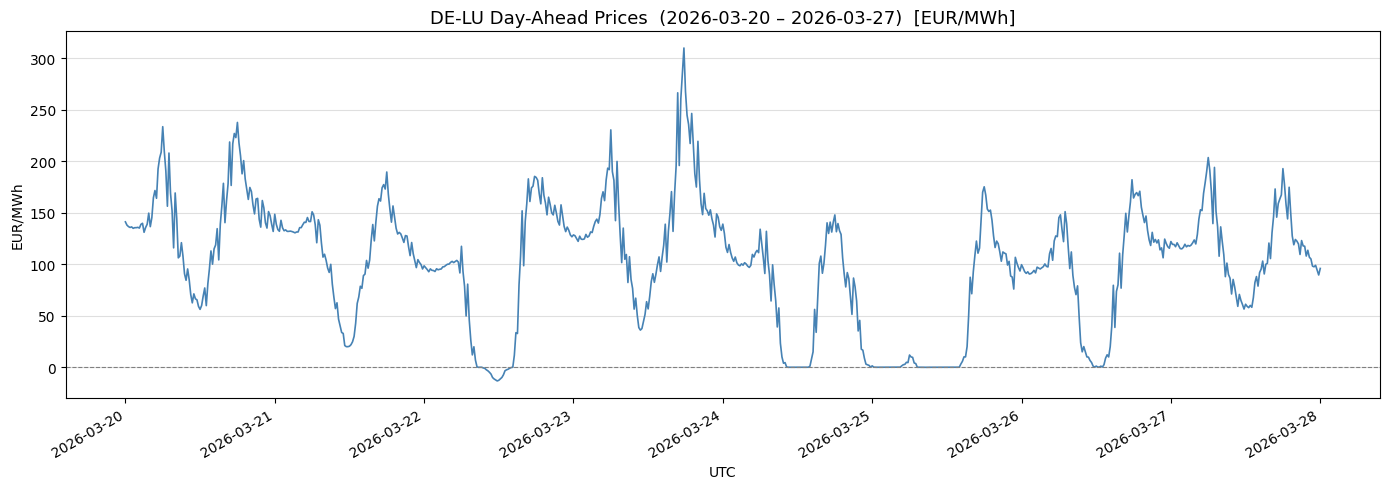

In [4]:
float_prices = prices["price_eur_mwh"].apply(float)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(float_prices.index, float_prices.values, linewidth=1.2, color="steelblue")
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_title(f"DE-LU Day-Ahead Prices  ({start} – {end})  [EUR/MWh]", fontsize=13)
ax.set_xlabel("UTC")
ax.set_ylabel("EUR/MWh")
ax.grid(axis="y", alpha=0.4)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Compare multiple bidding zones

Fetch the same window for a selection of Central Western European zones and overlay them.

In [5]:
zones = {
    "DE-LU": BiddingZone.DE_LU,
    "FR":    BiddingZone.FR,
    "BE":    BiddingZone.BE,
    "NL":    BiddingZone.NL,
}

frames: dict[str, pd.Series] = {}
for label, zone in zones.items():
    df = client.day_ahead_prices(zone=zone, start=start, end=end)
    frames[label] = df["price_eur_mwh"].apply(float)

comparison = pd.DataFrame(frames)
comparison.head()

,DE-LU,FR,BE,NL
2026-03-20 00:00:00+00:00,141.26,62.41,119.36,131.43
2026-03-20 00:15:00+00:00,138.09,55.28,115.07,127.75
2026-03-20 00:30:00+00:00,136.65,67.60,117.42,128.01
2026-03-20 00:45:00+00:00,135.84,68.67,117.13,127.44
2026-03-20 01:00:00+00:00,136.36,71.33,117.88,127.89


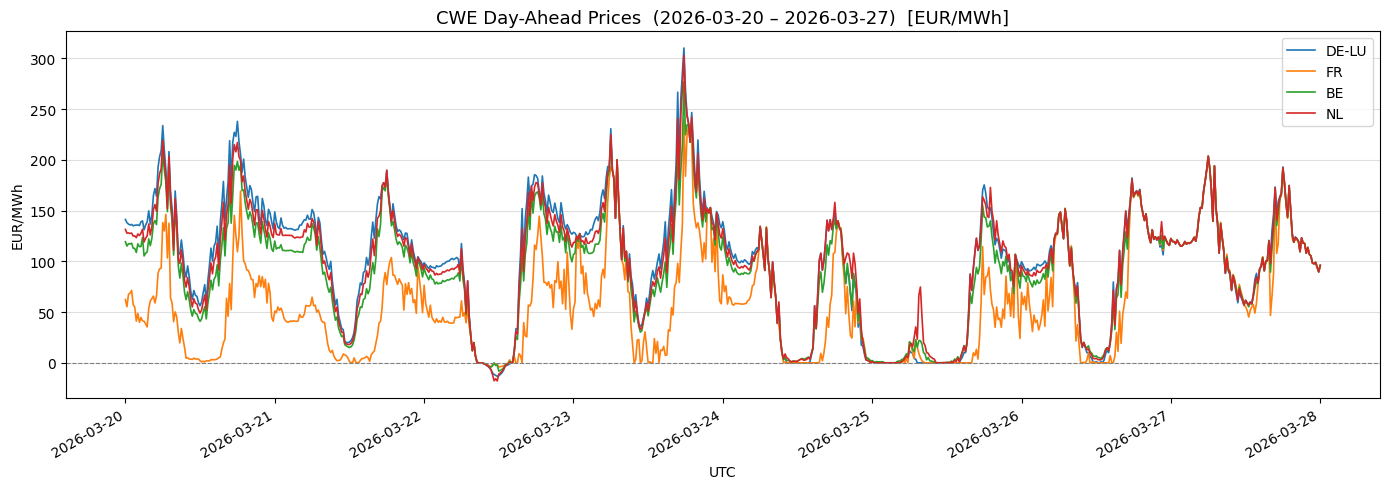

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
for col in comparison.columns:
    ax.plot(comparison.index, comparison[col], linewidth=1.2, label=col)
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_title(f"CWE Day-Ahead Prices  ({start} – {end})  [EUR/MWh]", fontsize=13)
ax.set_xlabel("UTC")
ax.set_ylabel("EUR/MWh")
ax.legend()
ax.grid(axis="y", alpha=0.4)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Daily average heatmap

Reshape the hourly data into a day × hour matrix and render it as a heatmap.
This makes it easy to spot daily patterns and overnight lows.

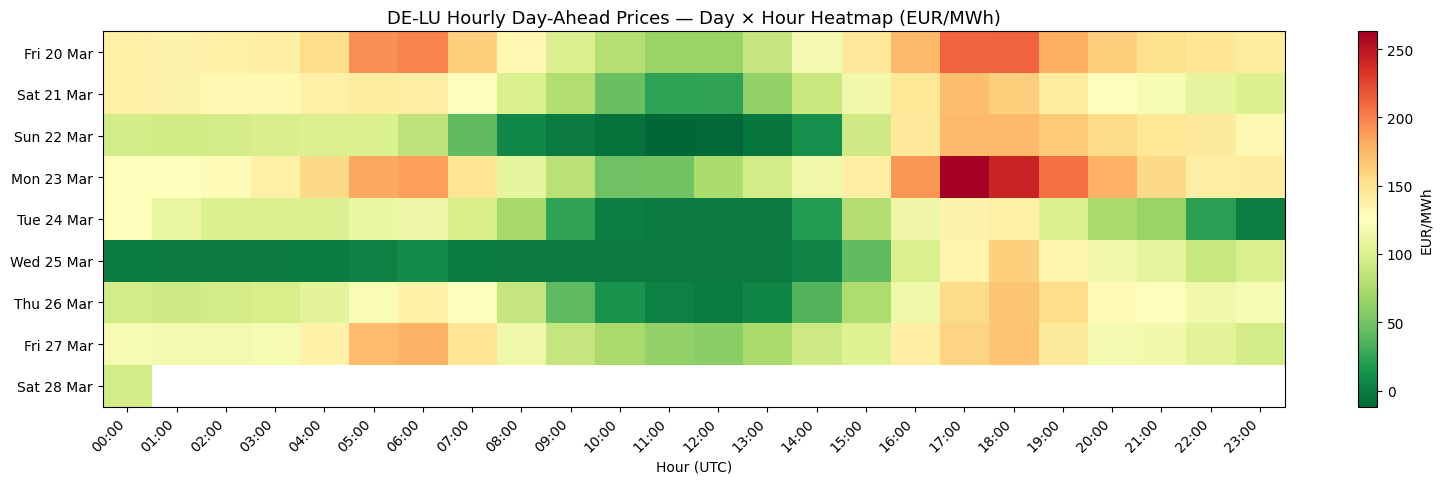

In [7]:
de_lu = frames["DE-LU"].copy()
de_lu_df = de_lu.to_frame(name="price")
de_lu_df["date"] = de_lu_df.index.normalize()
de_lu_df["hour"] = de_lu_df.index.hour

heatmap_data = de_lu_df.pivot_table(index="date", columns="hour", values="price")
heatmap_data.index = heatmap_data.index.strftime("%a %d %b")

fig, ax = plt.subplots(figsize=(16, max(3, len(heatmap_data) * 0.55)))
im = ax.imshow(heatmap_data.values, aspect="auto", cmap="RdYlGn_r")
plt.colorbar(im, ax=ax, label="EUR/MWh")
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels([f"{h:02d}:00" for h in heatmap_data.columns], rotation=45, ha="right")
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_title("DE-LU Hourly Day-Ahead Prices — Day × Hour Heatmap (EUR/MWh)", fontsize=13)
ax.set_xlabel("Hour (UTC)")
plt.tight_layout()
plt.show()

## Summary statistics

In [8]:
stats = comparison.agg(["min", "max", "mean", "std"]).T.rename(
    columns={"min": "Min", "max": "Max", "mean": "Mean", "std": "Std Dev"}
).round(2)
stats.index.name = "Zone"
stats

,Min,Max,Mean,Std Dev
Zone,,,,
DE-LU,-13.31,310.20,100.62,60.46
FR,-4.00,240.00,59.69,51.77
BE,-8.15,276.86,90.46,54.17
NL,-17.84,302.92,97.32,57.05
